# EDITOR CON CODIGOS DE PRUEBA

En este notebook contendra codigos de prueba para trabajar con datos de series de tiempo (time series), especialmente del libro time series forescasting, los codigos serviran para todo el tratamiento de las series de tiempo, como preparar la data para aprendizaje supervisado, y poder ingresarla adecuadamente a las redes neuronales CNN y LMTS, tambien la forma adecuada de modelar las CNN, sus entrenamiento y ajustes de los hiperparametros.

## Preparar los datos de series de tiempo

In [ ]:
''' 
Transforma los datos de una serie de tiempo univariada a un problema de aprendizaje supervisado
Crea una matriz de datos de entrada con n_steps como numero de columnas o caracteristicas,
"y" como la variable de salida
''' 

# split a univariate sequence into samples
def split_sequence(sequence, n_steps):
  X, y = list(), list()
  for i in range(len(sequence)):
  # find the end of this pattern
    end_ix = i + n_steps
    # check if we are beyond the sequence
    if end_ix > len(sequence)-1:
      break
    # gather input and output parts of the pattern
    seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
    X.append(seq_x)
    y.append(seq_y)
  return array(X), array(y)

In [ ]:
# transform univariate time series to supervised learning problem
from numpy import array
import pandas as pd

# define univariate time series
series = array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
print(series.shape)
# transform to a supervised learning problem
X, y = split_sequence(series, 3)
print(X.shape, y.shape)
# show each sample
for i in range(len(X)):
  print(X[i], y[i])

''' hay que tener presente que una sola serie de tiempo corresponde a:
    X[0] dimensionalidad 7: corresponde al numero de muestras - Sample (ref libro)
    X[1] dimensionalidad 3: corresponde a los pasos de tiempo - Time step (ref libro)
    Y dimensionalidad 1: corresponde a las etiquetas - Label (ref libro)
'''
# transform input from [samples, features] to [samples, timesteps, features]
X = X.reshape((X.shape[0], X.shape[1], 1))    # [7,3,1]

(10,)
(7, 3) (7,)
[1 2 3] 4
[2 3 4] 5
[3 4 5] 6
[4 5 6] 7
[5 6 7] 8
[6 7 8] 9
[7 8 9] 10


## **Estructura de ejemplo para preparar los datos de entrada X para una red neuronal LSTM o CNN.**

In [ ]:
# example of defining a dataset
from numpy import array

# define the dataset
data = list()
n = 5000
for i in range(n):
  data.append([i+1, (i+1)*10])
data = array(data)
print("5 muestras del vector: \n",data[:5, :])
print("vector data: \n",data.shape)

# drop time
data = data[:, 1]
print("elimina la columna del tiempo: \n",data.shape)

# split into samples (e.g. 5000/200 = 25)
samples = list()
length = 200
# step over the 5,000 in jumps of 200
for i in range(0,n,length):
  # grab from i to i + 200
  sample = data[i:i+length]
  samples.append(sample)
print("Divide los datos en filas de 200, para tener \n",len(samples), " secuencias")

# convert list of arrays into 2d array
data = array(samples)
print("Sample, timestep de los datos convertidos: \n",data.shape)

# reshape into [samples, timesteps, features]
data = data.reshape((len(samples), length, 1))
print("formato para trabajar CNN o LSTM: \n",data.shape)

5 muestras del vector: 
 [[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]
 [ 5 50]]
vector data: 
 (5000, 2)
elimina la columna del tiempo: 
 (5000,)
Divide los datos en filas de 200, para tener 
 25  secuencias
Sample, timestep de los datos convertidos: 
 (25, 200)
formato para trabajar CNN o LSTM: 
 (25, 200, 1)


## Estructura de datos multivariables para MLP

In [ ]:
# multivariate mlp example
from numpy import array
from numpy import hstack
from keras.models import Sequential
from keras.layers import Dense

# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
  X, y = list(), list()
  for i in range(len(sequences)):
    # find the end of this pattern
    end_ix = i + n_steps
    # check if we are beyond the dataset
    if end_ix > len(sequences):
      break
    # gather input and output parts of the pattern
    seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
    X.append(seq_x)
    y.append(seq_y)
  return array(X), array(y)

# define input sequence
in_seq1 = array([10, 20, 30, 40, 50, 60, 70, 80, 90])
in_seq2 = array([15, 25, 35, 45, 55, 65, 75, 85, 95])
out_seq = array([in_seq1[i]+in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))
print("la base de datos es ", dataset.shape)
print(dataset)
""" ---------- hasta aqui se creo la base de datos -------------"""

" Se divide a la forma (samples, time_step, features)"
# choose a number of time steps
n_steps = 3
# convert into input/output
X, y = split_sequences(dataset, n_steps)
print("\n se transforma para trabajar con modelos de DL ", X.shape)
print(X)
" Se crea el modelo MLP, se aplana los datos a un vector (1,time_step*features)"
# flatten input
n_input = X.shape[1] * X.shape[2]
Xtrain = X.reshape((X.shape[0], n_input))
print("\n Como es MLP es necesario aplanar los datos a un vector ", Xtrain.shape)
print(Xtrain)

# define model
model = Sequential()
model.add(Dense(100, activation='relu', input_dim=n_input))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(Xtrain, y, epochs=2000, verbose=0)
# demonstrate prediction
x_input = array([[80, 85], [90, 95], [100, 105]])
x_input = x_input.reshape((1, n_input))
yhat = model.predict(x_input, verbose=0)

print("prediccion")
print(yhat)

la base de datos es  (9, 3)
[[ 10  15  25]
 [ 20  25  45]
 [ 30  35  65]
 [ 40  45  85]
 [ 50  55 105]
 [ 60  65 125]
 [ 70  75 145]
 [ 80  85 165]
 [ 90  95 185]]

 se transforma para trabajar con modelos de DL  (7, 3, 2)
[[[10 15]
  [20 25]
  [30 35]]

 [[20 25]
  [30 35]
  [40 45]]

 [[30 35]
  [40 45]
  [50 55]]

 [[40 45]
  [50 55]
  [60 65]]

 [[50 55]
  [60 65]
  [70 75]]

 [[60 65]
  [70 75]
  [80 85]]

 [[70 75]
  [80 85]
  [90 95]]]

 Como es MLP es necesario aplanar los datos a un vector  (7, 6)
[[10 15 20 25 30 35]
 [20 25 30 35 40 45]
 [30 35 40 45 50 55]
 [40 45 50 55 60 65]
 [50 55 60 65 70 75]
 [60 65 70 75 80 85]
 [70 75 80 85 90 95]]
prediccion
[[205.43451]]


### **MLP model Multi-headed**

In [ ]:
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense
from keras.layers import concatenate

# Continunado con los datos X anteriores
# Se crea un modelo mlp por cada serie de tiempo o varible y se concatena su salida por una capa de salida
# a veces ofrece mejores rendimientos
# separate input data
X1 = X[:, :, 0]
X2 = X[:, :, 1]

print("Datos de cada variable")
print("X1: ", X1.shape, "X2: ", X2.shape)
print(X1, " y ", X2)

# first input model
visible1 = Input(shape=(n_steps,))
dense1 = Dense(100, activation='relu')(visible1)
# second input model
visible2 = Input(shape=(n_steps,))
dense2 = Dense(100, activation='relu')(visible2)
# merge input models
merge = concatenate([dense1, dense2])
output = Dense(1)(merge)
model = Model(inputs=[visible1, visible2], outputs=output)
model.compile(optimizer='adam', loss='mse')

# fit model
model.fit([X1, X2], y, epochs=2000, verbose=0)
# demonstrate prediction
x_input = array([[80, 85], [90, 95], [100, 105]])
x1 = x_input[:, 0].reshape((1, n_steps))
x2 = x_input[:, 1].reshape((1, n_steps))
yhat = model.predict([x1, x2], verbose=0)
print(yhat)

Datos de cada variable
X1:  (7, 3) X2:  (7, 3)
[[10 20 30]
 [20 30 40]
 [30 40 50]
 [40 50 60]
 [50 60 70]
 [60 70 80]
 [70 80 90]]  y  [[15 25 35]
 [25 35 45]
 [35 45 55]
 [45 55 65]
 [55 65 75]
 [65 75 85]
 [75 85 95]]
[[206.79782]]


## Estructura y modelos CNN

### CNN - 1D datos univariados

In [ ]:
# univariate cnn example
from numpy import array
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D

# split a univariate sequence into samples
def split_sequence(sequence, n_steps):
  X, y = list(), list()
  for i in range(len(sequence)):
    # find the end of this pattern
    end_ix = i + n_steps
    # check if we are beyond the sequence
    if end_ix > len(sequence)-1:
      break
    # gather input and output parts of the pattern
    seq_x, seq_y = sequence[i:end_ix], sequence[end_ix]
    X.append(seq_x)
    y.append(seq_y)
  return array(X), array(y)

# define input sequence
raw_seq = [10, 20, 30, 40, 50, 60, 70, 80, 90]
# choose a number of time steps
n_steps = 3
# split into samples
X, y = split_sequence(raw_seq, n_steps)
# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

# define model CNN-1D
model = Sequential()
model.add(Conv1D(64, 2, activation='relu', input_shape=(n_steps, n_features)))
model.add(MaxPooling1D())
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=1000, verbose=0)

# demonstrate prediction
x_input = array([70, 80, 90])
x_input = x_input.reshape((1, n_steps, n_features))
yhat = model.predict(x_input, verbose=0)
print(yhat)

[[101.44267]]


### CNN - 1D datos multivariados

In [ ]:
# multivariate cnn example
from numpy import array
from numpy import hstack
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
  X, y = list(), list()
  for i in range(len(sequences)):
    # find the end of this pattern
    end_ix = i + n_steps
    # check if we are beyond the dataset
    if end_ix > len(sequences):
      break
    # gather input and output parts of the pattern
    seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
    X.append(seq_x)
    y.append(seq_y)
  return array(X), array(y)

  # define input sequence
in_seq1 = array([10, 20, 30, 40, 50, 60, 70, 80, 90])
in_seq2 = array([15, 25, 35, 45, 55, 65, 75, 85, 95])
out_seq = array([in_seq1[i]+in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))
print("data original: ",dataset.shape)
# choose a number of time steps
n_steps = 3
# convert into input/output
X, y = split_sequences(dataset, n_steps)
print("X data: ", X.shape)
print("se transforma a: [samples, timestep, feature]")
# the dataset knows the number of features, e.g. 2
n_features = X.shape[2]
# define model
model = Sequential()
model.add(Conv1D(64, 2, activation='relu', input_shape=(n_steps, n_features)))
model.add(MaxPooling1D())
model.add(Flatten())
model.add(Dense(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=1000, verbose=0)
# demonstrate prediction
x_input = array([[80, 85], [90, 95], [100, 105]])
x_input = x_input.reshape((1, n_steps, n_features))
print("dato para predecir Xtest: ",x_input)
yhat = model.predict(x_input, verbose=0)
print("salida: ",yhat)

data original:  (9, 3)
X data:  (7, 3, 2)
se transforma a: [samples, timestep, feature]


dato para predecir Xtest:  [[[ 80  85]
  [ 90  95]
  [100 105]]]
salida:  [[206.98459]]


### CNN - 1D Multi-headed CNN Model

Hay otra forma más elaborada de modelar el problema. Cada serie de entrada puede ser manejada por una CNN separada y la salida de cada uno de estos submodelos se puede combinar antes de hacer una predicción para la secuencia de salida.

Los datos de entrada pasan de una matriz con la forma [7, 3, 2] a dos matrices 3D con [7, 3, 1] para cada submodelo CNN1D.

In [ ]:
# multivariate multi-headed 1d cnn example
from numpy import array
from numpy import hstack
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from keras.layers import concatenate

# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
  X, y = list(), list()
  for i in range(len(sequences)):
    # find the end of this pattern
    end_ix = i + n_steps
    # check if we are beyond the dataset
    if end_ix > len(sequences):
      break
    # gather input and output parts of the pattern
    seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
    X.append(seq_x)
    y.append(seq_y)
  return array(X), array(y)

# --------------------------------- PREPARANDO LA DATA -------------------
# define input sequence
in_seq1 = array([10, 20, 30, 40, 50, 60, 70, 80, 90])
in_seq2 = array([15, 25, 35, 45, 55, 65, 75, 85, 95])
out_seq = array([in_seq1[i]+in_seq2[i] for i in range(len(in_seq1))])
# convert to [rows, columns] structure
in_seq1 = in_seq1.reshape((len(in_seq1), 1))
in_seq2 = in_seq2.reshape((len(in_seq2), 1))
out_seq = out_seq.reshape((len(out_seq), 1))
# horizontally stack columns
dataset = hstack((in_seq1, in_seq2, out_seq))
# choose a number of time steps
n_steps = 3
# convert into input/output
X, y = split_sequences(dataset, n_steps)
# one time series per head
n_features = 1
# separate input data
X1 = X[:, :, 0].reshape(X.shape[0], X.shape[1], n_features)
X2 = X[:, :, 1].reshape(X.shape[0], X.shape[1], n_features)
print("Datos de cada variable")
print("X1: ", X1.shape, "X2: ", X2.shape)
print(X1, " y ", X2)

# -------------------------- CREANDO EL MODELO ---------------------
# first input model
visible1 = Input(shape=(n_steps, n_features))
cnn1 = Conv1D(64, 2, activation='relu')(visible1)
cnn1 = MaxPooling1D()(cnn1)
cnn1 = Flatten()(cnn1)
# second input model
visible2 = Input(shape=(n_steps, n_features))
cnn2 = Conv1D(64, 2, activation='relu')(visible2)
cnn2 = MaxPooling1D()(cnn2)
cnn2 = Flatten()(cnn2)
# merge input models
merge = concatenate([cnn1, cnn2])
dense = Dense(50, activation='relu')(merge)
output = Dense(1)(dense)
model = Model(inputs=[visible1, visible2], outputs=output)
model.compile(optimizer='adam', loss='mse')
# -------------------------- ENTRENANDO MODELO ---------------
# fit model
model.fit([X1, X2], y, epochs=1000, verbose=0)
# ------------------------- PREDICCIÓN -----------------------
# demonstrate prediction
x_input = array([[80, 85], [90, 95], [100, 105]])
x1 = x_input[:, 0].reshape((1, n_steps, n_features))
x2 = x_input[:, 1].reshape((1, n_steps, n_features))
print("vectores de prediccion: ", x1.shape, x2.shape)
print("X1: ", x1, " X2: ", x2)
yhat = model.predict([x1, x2], verbose=0)
print("prediccion: ",yhat)

Datos de cada variable
X1:  (7, 3, 1) X2:  (7, 3, 1)
[[[10]
  [20]
  [30]]

 [[20]
  [30]
  [40]]

 [[30]
  [40]
  [50]]

 [[40]
  [50]
  [60]]

 [[50]
  [60]
  [70]]

 [[60]
  [70]
  [80]]

 [[70]
  [80]
  [90]]]  y  [[[15]
  [25]
  [35]]

 [[25]
  [35]
  [45]]

 [[35]
  [45]
  [55]]

 [[45]
  [55]
  [65]]

 [[55]
  [65]
  [75]]

 [[65]
  [75]
  [85]]

 [[75]
  [85]
  [95]]]
vectores de prediccion:  (1, 3, 1) (1, 3, 1)
X1:  [[[ 80]
  [ 90]
  [100]]]  X2:  [[[ 85]
  [ 95]
  [105]]]
prediccion:  [[205.58316]]


Otras formas de modelar.

1.   Multiple Parallel Series (Cap 8 pag 103)

el caso donde se tiene multiples series o variables, y se desea predecir el valor para cada una.
En este modelo es identico en la entrada [samples, timesteps, features], la salida en cambio es igual al numero de valores a predecir es decir el numero de variables [out Dense(features)]

2.   Multi-output CNN Model (Cap 8 pag 106).

Cada serie de salida puede ser manejada por un modelo CNN de salida separado. La información ingresa al modelo CNN1d (capa CNN, Maxpooling, Dense) su salida ira dividida por serie a una capa Dense (FC) output. Model(inputs=visible, outputs=[output1, output2, output3])

3. Multi - step CNN Model Univariate

Predice la salida para multiples pasos de tiempo, es decir varias muestras en el futuro. X[10 20 30], Y[40 50], de la forma seq_x, seq_y = sequence[i:end_ix], sequence[end_ix:out_end_ix]. 
El modelo se crea de igual forma modelo CNN1d (capa CNN, Maxpooling, Dense) su salida sera el numero de pasos a predecir capa Dense (FC) output model.add(Dense(n_steps_out))

Multivariate Multi-step CNN Models

4. Multiple Input Multi-step Output

el caso donde se tiene multiples series o variables de entrada y se quiere predecir dos o más pasos de la serie (futuro). En este caso la entrada tiene que ser de la forma X[sample, timestep, features] y la salida sera en el n_steps de la forma Y[samples, n_stepts_outs]

5. Multiple Parallel Input and Multi-step Output

Para varias series de tiempo se requiere la prediccion de n pasos de tiempo para cada una de las series. X [sample, timestep, features] Y[samples, n_steps_outs, features].
Para el modelo se debe aplanar los datos de salida Y (tres dimensiones a una) por lo tanto para predicciones de 2 pasos en el tiempo para 3 variables, la salida sera un vector de 1x6.




## HAR Activity Example


### 1D CNN Model

In [1]:
from google.colab import drive    # Montar Drive
drive.mount('/content/drive')     # Su Google Drive
 # Direccion de la carpeta
%cd drive/MyDrive/Colab_Notebooks/Tesis_Maestria/Datasets

Mounted at /content/drive
/content/drive/MyDrive/Colab_Notebooks/Tesis_Maestria/Datasets


In [2]:
# cnn model for the har dataset
from numpy import mean
from numpy import std
from numpy import dstack
from pandas import read_csv
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from keras.utils import to_categorical

# ----------------- Funciones para Cargar los datos. -----------

# load a single file as a numpy array
def load_file(filepath):
  dataframe = read_csv(filepath, header=None, delim_whitespace=True)
  return dataframe.values

# load a list of files into a 3D array of [samples, timesteps, features]
def load_group(filenames, prefix=''):
  loaded = list()
  for name in filenames:
    data = load_file(prefix + name)
    loaded.append(data)
  # stack group so that features are the 3rd dimension
  loaded = dstack(loaded)
  return loaded

# load all input signal data for a given group, such as train or test.
def load_dataset_group(group, prefix=''):
  filepath = prefix + group + '/Inertial Signals/'
  # load all 9 files as a single array
  filenames = list()
  # total acceleration
  filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt',
    'total_acc_z_'+group+'.txt']
  # body acceleration
  filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt',
    'body_acc_z_'+group+'.txt']
  # body gyroscope
  filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt',
    'body_gyro_z_'+group+'.txt']
  # load input data
  X = load_group(filenames, filepath)
  # load class output
  y = load_file(prefix + group + '/y_'+group+'.txt')
  return X, y

# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
  # load all train
  trainX, trainy = load_dataset_group('train', prefix + 'UCI HAR Dataset/')
  print(trainX.shape, trainy.shape)
  # load all test
  testX, testy = load_dataset_group('test', prefix + 'UCI HAR Dataset/')
  print(testX.shape, testy.shape)
  # zero-offset class values
  trainy = trainy - 1
  testy = testy - 1
  ''' one hot encode y to modelate CNN'''
  trainy = to_categorical(trainy)
  testy = to_categorical(testy)
  print(trainX.shape, trainy.shape, testX.shape, testy.shape)
  return trainX, trainy, testX, testy


## ----------------------- DEFINICION MODELO 1D CNN -------------------

# fit and evaluate a model
def evaluate_model(trainX, trainy, testX, testy):
  verbose, epochs, batch_size = 0, 10, 32
  # define data shape
  n_timesteps, n_features, n_outputs = trainX.shape[1], trainX.shape[2], trainy.shape[1]

  # define the CNN model
  model = Sequential()
  model.add(Conv1D(64, 3, activation='relu', input_shape=(n_timesteps,n_features)))
  model.add(Conv1D(64, 3, activation='relu'))
  model.add(Dropout(0.5))
  model.add(MaxPooling1D())
  model.add(Flatten())
  model.add(Dense(100, activation='relu'))
  model.add(Dense(n_outputs, activation='softmax'))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  # fit network
  model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose)
  # evaluate model
  _, accuracy = model.evaluate(testX, testy, batch_size=batch_size, verbose=0)
  return accuracy

# --------------- Evaluacion del modelo -----------------
# summarize scores
def summarize_results(scores):
  print(scores)
  m, s = mean(scores), std(scores)
  print('Accuracy: %.3f%% (+/-%.3f)' % (m, s))

# run an experiment
def run_experiment(repeats=10):
  # load data
  trainX, trainy, testX, testy = load_dataset()
  # repeat experiment
  scores = list()
  for r in range(repeats):
    score = evaluate_model(trainX, trainy, testX, testy)
    score = score * 100.0
    print('>#%d: %.3f' % (r+1, score))
    scores.append(score)
  # summarize results
  summarize_results(scores)

# ----------------------- Ejecuto el programa ------------------
# run the experiment
run_experiment()

(7352, 128, 9) (7352, 1)
(2947, 128, 9) (2947, 1)
(7352, 128, 9) (7352, 6) (2947, 128, 9) (2947, 6)
>#1: 88.802
>#2: 89.481
>#3: 91.381
>#4: 90.227
>#5: 90.159
>#6: 88.090
>#7: 90.329
>#8: 91.619
>#9: 91.144
>#10: 92.026
[88.802170753479, 89.4808292388916, 91.3810670375824, 90.22734761238098, 90.15948176383972, 88.08958530426025, 90.32914638519287, 91.6185975074768, 91.14353656768799, 92.02578663825989]
Accuracy: 90.326% (+/-1.201)


### Tunned CNN Model

#### Preparación de los datos.


1.   Estandarizar los datos: dejar cada variable con media cero y varianza unitaria, esto es cambiar el rango de cada variable. Ahora esto permite que una normalizacion de los datos, solo se puede hacer si las variables tienen una distribucion gausiana.
  
  1.1 Remover la ventana de traslape. usan una eliminacion de cada muestra en la mitad de la ventana, perdiendo estos datos y quedandose solo con la segunda mitad.

  1.2 Estandarizacion: Se obtiene la media y desviacion estandar de los datos de train. Se aplica la estandarización sobre los datos de train y test.




(7352, 128, 9) (7352, 1)
(2947, 128, 9) (2947, 1)
(7352, 128, 9) (7352, 6) (2947, 128, 9) (2947, 6)


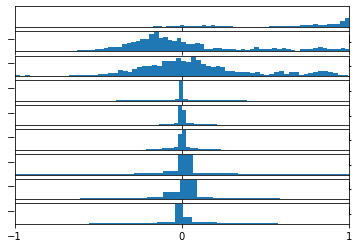

(7352, 128, 9) (7352, 1)
(2947, 128, 9) (2947, 1)
(7352, 128, 9) (7352, 6) (2947, 128, 9) (2947, 6)
>p=0 #1: 91.754
>p=0 #2: 91.653
>p=0 #3: 89.786
>p=0 #4: 91.381
>p=0 #5: 90.329
>p=0 #6: 89.820
>p=0 #7: 89.209
>p=0 #8: 90.058
>p=0 #9: 92.060
>p=0 #10: 90.635
>p=1 #1: 89.277
>p=1 #2: 92.365
>p=1 #3: 91.483
>p=1 #4: 91.856
>p=1 #5: 89.074
>p=1 #6: 91.245
>p=1 #7: 91.585
>p=1 #8: 91.551
>p=1 #9: 89.413
>p=1 #10: 90.635
[[91.75432920455933, 91.65253043174744, 89.78622555732727, 91.3810670375824, 90.32914638519287, 89.8201584815979, 89.20936584472656, 90.05768299102783, 92.05971956253052, 90.63454270362854], [89.27723169326782, 92.36511588096619, 91.48286581039429, 91.85612201690674, 89.07363414764404, 91.24533534049988, 91.58466458320618, 91.55073165893555, 89.41296339035034, 90.63454270362854]] [False, True]
Param=0: 90.668% (+/-0.933)
Param=1: 90.848% (+/-1.124)


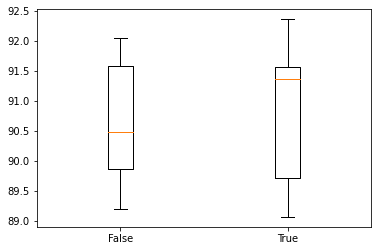

In [ ]:
# plot distributions for the har dataset
from numpy import dstack
from pandas import read_csv
from keras.utils import to_categorical
from matplotlib import pyplot
from sklearn.preprocessing import StandardScaler

' usan la mismas funciones de 1D CNN Model para cargar los datos'

# plot a histogram of each variable in the dataset
def plot_variable_distributions(trainX):
  # 1.1 remove overlap
  cut = int(trainX.shape[1] / 2)
  longX = trainX[:, -cut:, :]
  # flatten windows
  longX = longX.reshape((longX.shape[0] * longX.shape[1], longX.shape[2]))
  pyplot.figure()
  for i in range(longX.shape[1]):
    # create figure
    ax = pyplot.subplot(longX.shape[1], 1, i+1)
    ax.set_xlim(-1, 1)
    # create histogram
    pyplot.hist(longX[:, i], bins=100)
    # simplify axis remove clutter
    pyplot.yticks([])
    pyplot.xticks([-1,0,1])
  pyplot.show()

# load data
trainX, trainy, testX, testy = load_dataset()
# plot histograms
plot_variable_distributions(trainX)

# 1.2 standardize data
def scale_data(trainX, testX, standardize):
  # remove overlap
  cut = int(trainX.shape[1] / 2)
  longX = trainX[:, -cut:, :]
  # flatten windows
  longX = longX.reshape((longX.shape[0] * longX.shape[1], longX.shape[2]))
  # flatten train and test
  flatTrainX = trainX.reshape((trainX.shape[0] * trainX.shape[1], trainX.shape[2]))
  flatTestX = testX.reshape((testX.shape[0] * testX.shape[1], testX.shape[2]))
  # standardize varieble [false, true]
  if standardize:
    s = StandardScaler()
    # fit on training data
    s.fit(longX)
    # apply to training and test data
    longX = s.transform(longX)
    flatTrainX = s.transform(flatTrainX)
    flatTestX = s.transform(flatTestX)
  # reshape
  flatTrainX = flatTrainX.reshape((trainX.shape))
  flatTestX = flatTestX.reshape((testX.shape))
  return flatTrainX, flatTestX

# fit and evaluate a model with standardize
def evaluate_model(trainX, trainy, testX, testy, param):
  verbose, epochs, batch_size = 0, 10, 32
  n_timesteps, n_features, n_outputs = trainX.shape[1], trainX.shape[2], trainy.shape[1]
  # scale data
  trainX, testX = scale_data(trainX, testX, param)
  model = Sequential()
  model.add(Conv1D(64, 3, activation='relu', input_shape=(n_timesteps,n_features)))
  model.add(Conv1D(64, 3, activation='relu'))
  model.add(Dropout(0.5))
  model.add(MaxPooling1D())
  model.add(Flatten())
  model.add(Dense(100, activation='relu'))
  model.add(Dense(n_outputs, activation='softmax'))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  # fit network
  model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose)
  # evaluate model
  _, accuracy = model.evaluate(testX, testy, batch_size=batch_size, verbose=0)
  return accuracy

# summarize scores
def summarize_results(scores, params):
  print(scores, params)
  # summarize mean and standard deviation
  for i in range(len(scores)):
    m, s = mean(scores[i]), std(scores[i])
    print('Param=%d: %.3f%% (+/-%.3f)' % (params[i], m, s))
  # box plot of scores
  pyplot.boxplot(scores, labels=params)
  #pyplot.savefig('exp_cnn_standardize.png')

# run an experiment
def run_experiment(params, repeats=10):
  # load data
  trainX, trainy, testX, testy = load_dataset()
  # test each parameter
  all_scores = list()
  for p in params:
    # repeat experiment
    scores = list()
    for r in range(repeats):
      score = evaluate_model(trainX, trainy, testX, testy, p)
      score = score * 100.0
      print('>p=%d #%d: %.3f' % (p, r+1, score))
      scores.append(score)
    all_scores.append(scores)
  # summarize results
  summarize_results(all_scores, params)

# run the experiment
n_params = [False, True]   # False no realiza standarizacion, True si la realiza
run_experiment(n_params)

#### Numero de filtros.

(7352, 128, 9) (7352, 1)
(2947, 128, 9) (2947, 1)
(7352, 128, 9) (7352, 6) (2947, 128, 9) (2947, 6)
>p=8 #1: 86.664
>p=8 #2: 89.650
>p=8 #3: 89.243
>p=8 #4: 88.395
>p=8 #5: 88.565
>p=8 #6: 87.139
>p=8 #7: 90.261
>p=8 #8: 89.379
>p=8 #9: 88.565
>p=8 #10: 88.531
>p=16 #1: 90.058
>p=16 #2: 89.175
>p=16 #3: 89.922
>p=16 #4: 89.515
>p=16 #5: 89.040
>p=16 #6: 91.890
>p=16 #7: 89.481
>p=16 #8: 89.854
>p=16 #9: 89.209
>p=16 #10: 90.363
>p=32 #1: 90.397
>p=32 #2: 89.922
>p=32 #3: 90.533
>p=32 #4: 90.601
>p=32 #5: 91.788
>p=32 #6: 88.972
>p=32 #7: 90.736
>p=32 #8: 88.225
>p=32 #9: 89.074
>p=32 #10: 89.243
>p=64 #1: 91.279
>p=64 #2: 88.259
>p=64 #3: 88.870
>p=64 #4: 91.822
>p=64 #5: 88.565
>p=64 #6: 83.135
>p=64 #7: 89.345
>p=64 #8: 92.060
>p=64 #9: 90.431
>p=64 #10: 91.177
>p=128 #1: 90.567
>p=128 #2: 90.363
>p=128 #3: 90.465
>p=128 #4: 90.770
>p=128 #5: 92.908
>p=128 #6: 91.110
>p=128 #7: 91.788
>p=128 #8: 91.483
>p=128 #9: 92.229
>p=128 #10: 92.128
>p=256 #1: 90.024
>p=256 #2: 89.752
>p=256 #3

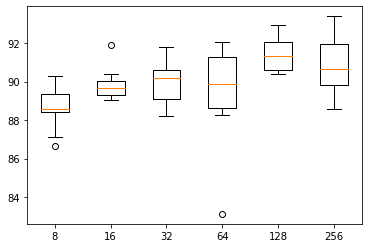

In [ ]:
# Se realiza una busqueda del número de mapas de filtros
# de forma iterativa se aumenta los filtros y se entrena y prueba el modelo

'se realiza usando las mismas funciones de los codigos pasados desde 1D CNN'
'Se modifico la funcion evaluate_model y run_experiment'
'para que acepte como parametros la lista de número de filtros'

# define configuration de filtros a iterar
n_params = [8, 16, 32, 64, 128, 256]

# fit and evaluate a model
def evaluate_model(trainX, trainy, testX, testy, n_filters):
  verbose, epochs, batch_size = 0, 10, 32
  n_timesteps, n_features, n_outputs = trainX.shape[1], trainX.shape[2], trainy.shape[1]
  model = Sequential()
  model.add(Conv1D(n_filters, 3, activation='relu', input_shape=(n_timesteps,n_features)))
  model.add(Conv1D(n_filters, 3, activation='relu'))
  model.add(Dropout(0.5))
  model.add(MaxPooling1D())
  model.add(Flatten())
  model.add(Dense(100, activation='relu'))
  model.add(Dense(n_outputs, activation='softmax'))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  # fit network
  model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose)
  # evaluate model
  _, accuracy = model.evaluate(testX, testy, batch_size=batch_size, verbose=0)
  return accuracy

# run an experiment
def run_experiment(params, repeats=10):
  # load data
  trainX, trainy, testX, testy = load_dataset()
  # test each parameter
  all_scores = list()
  for p in params:
    # repeat experiment
    scores = list()
    for r in range(repeats):
      score = evaluate_model(trainX, trainy, testX, testy, p)
      score = score * 100.0
      print('>p=%d #%d: %.3f' % (p, r+1, score))
      scores.append(score)
    all_scores.append(scores)
  # summarize results
  summarize_results(all_scores, params)

# run the experiment
n_params = [8, 16, 32, 64, 128, 256]
run_experiment(n_params)

#### Tamaño del Kernel.

(7352, 128, 9) (7352, 1)
(2947, 128, 9) (2947, 1)
(7352, 128, 9) (7352, 6) (2947, 128, 9) (2947, 6)
>p=2 #1: 89.617
>p=2 #2: 88.802
>p=2 #3: 88.497
>p=2 #4: 88.599
>p=2 #5: 89.650
>p=2 #6: 91.415
>p=2 #7: 88.225
>p=2 #8: 90.465
>p=2 #9: 91.822
>p=2 #10: 88.972
>p=3 #1: 90.159
>p=3 #2: 91.347
>p=3 #3: 91.110
>p=3 #4: 89.990
>p=3 #5: 90.668
>p=3 #6: 90.974
>p=3 #7: 90.363
>p=3 #8: 89.718
>p=3 #9: 89.209
>p=3 #10: 90.974
>p=5 #1: 90.838
>p=5 #2: 91.822
>p=5 #3: 91.381
>p=5 #4: 91.381
>p=5 #5: 91.177
>p=5 #6: 90.533
>p=5 #7: 91.483
>p=5 #8: 91.144
>p=5 #9: 91.890
>p=5 #10: 90.329
>p=7 #1: 92.976
>p=7 #2: 90.363
>p=7 #3: 90.397
>p=7 #4: 88.700
>p=7 #5: 91.347
>p=7 #6: 91.992
>p=7 #7: 90.668
>p=7 #8: 89.786
>p=7 #9: 89.379
>p=7 #10: 91.788
>p=11 #1: 90.635
>p=11 #2: 91.347
>p=11 #3: 91.924
>p=11 #4: 89.447
>p=11 #5: 91.211
>p=11 #6: 91.177
>p=11 #7: 89.549
>p=11 #8: 89.990
>p=11 #9: 91.008
>p=11 #10: 91.110
[[89.61656093597412, 88.802170753479, 88.49677443504333, 88.59857320785522, 89.650493

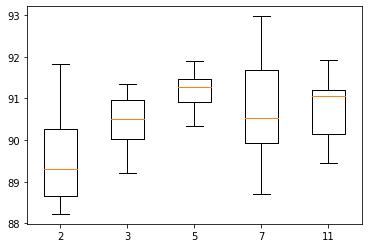

In [ ]:
# define configuration
n_params = [2, 3, 5, 7, 11]

'Se usa las mismas funciones anteriores desde 1D CNN Model'
'se modifican las funciones evaluate_model '

# fit and evaluate a model
def evaluate_model(trainX, trainy, testX, testy, n_kernel):
  verbose, epochs, batch_size = 0, 15, 32
  n_timesteps, n_features, n_outputs = trainX.shape[1], trainX.shape[2], trainy.shape[1]
  model = Sequential()
  model.add(Conv1D(64, n_kernel, activation='relu', input_shape=(n_timesteps,n_features)))
  model.add(Conv1D(64, n_kernel, activation='relu'))
  model.add(Dropout(0.5))
  model.add(MaxPooling1D())
  model.add(Flatten())
  model.add(Dense(100, activation='relu'))
  model.add(Dense(n_outputs, activation='softmax'))
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  # fit network
  model.fit(trainX, trainy, epochs=epochs, batch_size=batch_size, verbose=verbose)
  # evaluate model
  _, accuracy = model.evaluate(testX, testy, batch_size=batch_size, verbose=0)
  return accuracy

# run the experiment
n_params = [2, 3, 5, 7, 11]
run_experiment(n_params)

### Multi-Headed 1D CNN Model.

In [5]:
'Crea un modelo Multi-Headed de varias cabeceras de entrada'
'a su salida se concatenan y pasan a un FC y a la salida'

'Usa las mismas funciones para cargar los datos'
'Modifica el modelo en evaluate_model()'
'summarize_results y run_experiment son las funciones originales de 1D CNN'

from keras.utils.vis_utils import plot_model
from keras.models import Model
from keras.layers import Input
from keras.layers import Dense
from keras.layers import Flatten
from keras.layers import Dropout
from keras.layers.convolutional import Conv1D
from keras.layers.convolutional import MaxPooling1D
from keras.layers import concatenate

# fit and evaluate a model
def evaluate_model(trainX, trainy, testX, testy):
  verbose, epochs, batch_size = 0, 10, 32
  n_timesteps, n_features, n_outputs = trainX.shape[1], trainX.shape[2], trainy.shape[1]
  # head 1
  inputs1 = Input(shape=(n_timesteps,n_features))
  conv1 = Conv1D(64, 3, activation='relu')(inputs1)
  drop1 = Dropout(0.5)(conv1)
  pool1 = MaxPooling1D()(drop1)
  flat1 = Flatten()(pool1)
  # head 2
  inputs2 = Input(shape=(n_timesteps,n_features))
  conv2 = Conv1D(64, 5, activation='relu')(inputs2)
  drop2 = Dropout(0.5)(conv2)
  pool2 = MaxPooling1D()(drop2)
  flat2 = Flatten()(pool2)
  # head 3
  inputs3 = Input(shape=(n_timesteps,n_features))
  conv3 = Conv1D(64, 11, activation='relu')(inputs3)
  drop3 = Dropout(0.5)(conv3)
  pool3 = MaxPooling1D()(drop3)
  flat3 = Flatten()(pool3)
  # merge
  merged = concatenate([flat1, flat2, flat3])
  # interpretation
  dense1 = Dense(100, activation='relu')(merged)
  outputs = Dense(n_outputs, activation='softmax')(dense1)
  model = Model(inputs=[inputs1, inputs2, inputs3], outputs=outputs)
  # save a plot of the model
  plot_model(model, show_shapes=True, to_file='multiheaded.png')
  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
  # fit network
  model.fit([trainX,trainX,trainX], trainy, epochs=epochs, batch_size=batch_size,
  verbose=verbose)
  # evaluate model
  _, accuracy = model.evaluate([testX,testX,testX], testy, batch_size=batch_size, verbose=0)
  return accuracy

# summarize scores
def summarize_results(scores):
  print(scores)
  m, s = mean(scores), std(scores)
  print('Accuracy: %.3f%% (+/-%.3f)' % (m, s))

# run an experiment
def run_experiment(repeats=10):
  # load data
  trainX, trainy, testX, testy = load_dataset()
  # repeat experiment
  scores = list()
  for r in range(repeats):
    score = evaluate_model(trainX, trainy, testX, testy)
    score = score * 100.0
    print('>#%d: %.3f' % (r+1, score))
    scores.append(score)
  # summarize results
  summarize_results(scores)

run_experiment()

(7352, 128, 9) (7352, 1)
(2947, 128, 9) (2947, 1)
(7352, 128, 9) (7352, 6) (2947, 128, 9) (2947, 6)
>#1: 92.229
>#2: 90.193
>#3: 92.976
>#4: 93.180
>#5: 93.349
>#6: 93.655
>#7: 92.162
>#8: 90.499
>#9: 92.569
>#10: 90.906
[92.22938418388367, 90.19341468811035, 92.97590851783752, 93.1795060634613, 93.34917068481445, 93.65456104278564, 92.16151833534241, 90.49881100654602, 92.56871342658997, 90.90600609779358]
Accuracy: 92.172% (+/-1.171)
